# ICU Census, LOS, and Discharge Modeling

**Goal of this notebook**

This notebook shows our work for the ICU / inpatient flow project.  
We specifically address the feedback to:

1. Develop an arrival-process model with engineered features (daily arrivals, lags, rolling stats).
2. Analyze length of stay (LOS) by level of care and build LOS-based models.
3. Model LOS distributions and use them to predict daily discharges.
4. Bridge arrivals + LOS + discharges to **ICU census**.
5. Explore short vs long stays and departures/exits, and start building dashboard-style visuals.

Each step below is numbered and documented so our reasoning is explicit.


In [44]:
# Step 1 â€“ Mount Google Drive and define healthcare data paths
from google.colab import drive
drive.mount('/content/drive')

# Navigate to your Healthcare folder
import os

# Update this path if your folder structure is different
healthcare_folder = '/content/drive/MyDrive/Healthcare'

# Check if the folder exists and list files
if os.path.exists(healthcare_folder):
    print("âœ… Healthcare folder found!")
    print("\nFiles in your Healthcare folder:")
    print("-" * 50)

    files = os.listdir(healthcare_folder)
    for file in files:
        if '.xlsx' in file.lower():
            file_path = os.path.join(healthcare_folder, file)
            file_size = os.path.getsize(file_path) / (1024*1024)  # Size in MB
            print(f"   ðŸ“Š {file} ({file_size:.2f} MB)")
else:
    print("âŒ Healthcare folder not found.")
    print("Let me check your Drive structure...")
    print("\nFolders in MyDrive:")
    mydrive_contents = os.listdir('/content/drive/MyDrive/')
    for item in mydrive_contents[:10]:  # Show first 10 items
        print(f"  - {item}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
âœ… Healthcare folder found!

Files in your Healthcare folder:
--------------------------------------------------
   ðŸ“Š Teletracking02.24_01.25DEID.xlsx (1.50 MB)
   ðŸ“Š Daily inpatient level of care.xlsx (5.82 MB)


## Step 2 â€“ Load and clean Daily Inpatient Level of Care and TeleTracking data

**What we do here**

- Detect the correct header row in the *Daily Inpatient Level of Care* extract.
- Reload the file using that header row and standardize column names:
  - `Proxy Enc ID â†’ Proxy_Enc_ID`
  - `Med/Surg â†’ Med_Surg`
- Load the TeleTracking extract and convert `Bedrequest Timestamp` to datetime.

**Why this matters**

This step creates two clean base tables:

- `daily_care`: encounter-level IP days by level of care (ICU, Med_Surg, PCU, Tele, Total).
- `teletrack`: bed requests and timestamps used for arrival modeling and ED throughput.

This addresses the basic data-prep part of the feedback: getting reliable counts of encounters and bed requests per day.


In [45]:
# Step 2 â€“ Load and clean Daily Inpatient Level of Care and TeleTracking data
import pandas as pd
import numpy as np

healthcare_folder = '/content/drive/MyDrive/Healthcare'
daily_care_file = f'{healthcare_folder}/Daily inpatient level of care.xlsx'
teletrack_file = f'{healthcare_folder}/Teletracking02.24_01.25DEID.xlsx'

print("Loading data with proper headers...")
print("=" * 60)

# 1. Preview raw file WITHOUT assuming a header
print("1. Preview Daily Inpatient Level of Care (raw)...")
daily_care_preview = pd.read_excel(daily_care_file, header=None, nrows=20)
print(daily_care_preview)
print("\n" + "-"*60)

# 2. Find the row where the first column is 'Proxy Enc ID' -> real header row
header_row_idx = daily_care_preview[
    daily_care_preview.iloc[:, 0] == "Proxy Enc ID"
].index[0]

print(f"Detected header row at index: {header_row_idx}")

# # 3. Re-load using that row as header (skip rows ABOVE it)
# daily_care = pd.read_excel(daily_care_file, skiprows=header_row_idx)

# print(f"\nDaily Inpatient Data Shape: {daily_care.shape}")
# print("First 5 rows:")
# display(daily_care.head())
# print("\nColumns:")
# print(list(daily_care.columns))
# print("\n" + "-"*60)

# 3. Re-load using that row as header (skip rows ABOVE it)
daily_care = pd.read_excel(daily_care_file, skiprows=header_row_idx)

# Standardize column names so later steps can use Med_Surg
daily_care = daily_care.rename(columns={
    'Proxy Enc ID': 'Proxy_Enc_ID',
    'Med/Surg': 'Med_Surg'
})

print(f"\nDaily Inpatient Data Shape: {daily_care.shape}")
print("First 5 rows:")
display(daily_care.head())
print("\nColumns:")
print(list(daily_care.columns))


# 4. Load Teletracking properly so teletrack is defined
print("2. Loading Teletracking data...")
teletrack = pd.read_excel(teletrack_file)
print(f"Teletracking Shape: {teletrack.shape}")
print("Teletracking Columns (first 10):")
print(list(teletrack.columns[:10]))


Loading data with proper headers...
1. Preview Daily Inpatient Level of Care (raw)...
               0              1         2     3     4      5
0            NaN            NaN       NaN   NaN   NaN    NaN
1            NaN            NaN       NaN   NaN   NaN    NaN
2        IP Days  Level of Care       NaN   NaN   NaN    NaN
3            NaN            ICU  Med/Surg   PCU  Tele  Total
4          Total          28299     29624  4714  1207  63844
5            NaN            NaN       NaN   NaN   NaN    NaN
6            NaN            NaN       NaN   NaN   NaN    NaN
7           6451     encounters       NaN   NaN   NaN    NaN
8            NaN            NaN       NaN   NaN   NaN    NaN
9        IP Days  Level of Care       NaN   NaN   NaN    NaN
10  Proxy Enc ID            ICU  Med/Surg   PCU  Tele  Total
11      41726460             26       408    15   NaN    449
12      24770287              1       301   NaN   NaN    302
13      81745484              1       296   NaN   NaN    297

,Proxy_Enc_ID,ICU,Med_Surg,PCU,Tele,Total
0,41726460,26.0,408.0,15.0,NaN,449
1,24770287,1.0,301.0,NaN,NaN,302
2,81745484,1.0,296.0,NaN,NaN,297
3,33584437,11.0,254.0,NaN,NaN,265
4,78560450,11.0,223.0,NaN,NaN,234



Columns:
['Proxy_Enc_ID', 'ICU', 'Med_Surg', 'PCU', 'Tele', 'Total']
2. Loading Teletracking data...
Teletracking Shape: (20431, 12)
Teletracking Columns (first 10):
['Origin Unit Category', 'Origin Unit', 'Occupied Unit', 'Origin Campus', 'Placement Status', 'Placement Type', 'Requested Level Of Care', 'Bedrequest Timestamp', 'ED Bed Request To Bed Occupy Time', 'Rtm To Bedassigned Time']


## Step 3 â€“ Arrival features with no leakage

**What we do here**

- Aggregate TeleTracking bed requests to daily **arrival counts**.
- Build time-series features using only past information:
  - Lagged arrivals (1, 3, 7, 14 days).
  - Rolling means and standard deviations (shifted so they use only historical values).
- Add calendar features (day of week, weekend flag, month, week of year).
- Save the feature matrix as `arrival_features.csv`.

**Why this matters**

This step directly addresses the professorâ€™s request to _â€œdevelop analysis of the arrival process (internal and external)â€¦ engineered variablesâ€¦ how many arrivals each day.â€_  

The output of this step is the design matrix we use later in the arrival Random Forest model (Steps 11â€“12), and it is explicitly **no-leakage** (tomorrowâ€™s prediction only uses information available up to today).


In [46]:
# Step 3 â€“ Build daily arrival features from TeleTracking (no leakage)
import pandas as pd, numpy as np

# ensure timestamps
teletrack['Bedrequest Timestamp'] = pd.to_datetime(teletrack['Bedrequest Timestamp'])
teletrack['Date'] = teletrack['Bedrequest Timestamp'].dt.date
daily = teletrack.groupby('Date').size().reset_index(name='arrivals')
daily['Date'] = pd.to_datetime(daily['Date'])

# full date index
idx = pd.date_range(daily['Date'].min(), daily['Date'].max(), freq='D')
df = pd.DataFrame(index=idx)
df['arrivals'] = daily.set_index('Date')['arrivals'].reindex(idx).fillna(0)

# lags
for k in [1,3,7,14]:
    df[f'arrivals_lag{k}'] = df['arrivals'].shift(k)

# rolling stats computed on the **lagged series** (past-only)
df['arrivals_ma7']  = df['arrivals'].shift(1).rolling(7,  min_periods=7).mean()
df['arrivals_ma14'] = df['arrivals'].shift(1).rolling(14, min_periods=14).mean()
df['arrivals_std7'] = df['arrivals'].shift(1).rolling(7,  min_periods=7).std()

# calendar
df['day_of_week'] = df.index.dayofweek
df['is_weekend']  = (df['day_of_week']>=5).astype(int)
df['month']       = df.index.month
df['week_of_year']= df.index.isocalendar().week.astype(int)

# drop early rows that cannot have full windows
features = df.dropna().copy()
features.to_csv('arrival_features.csv')  # overwrite with clean set
print("âœ… Rebuilt (no-leak) 'arrival_features.csv' from", features.index.min().date(), "to", features.index.max().date())
print("Columns:", list(features.columns))


âœ… Rebuilt (no-leak) 'arrival_features.csv' from 2024-02-15 to 2025-01-30
Columns: ['arrivals', 'arrivals_lag1', 'arrivals_lag3', 'arrivals_lag7', 'arrivals_lag14', 'arrivals_ma7', 'arrivals_ma14', 'arrivals_std7', 'day_of_week', 'is_weekend', 'month', 'week_of_year']


## Step 4 â€“ LOS exploratory analysis by level of care

**What we do here**

- Derive LOS by level of care for each encounter:
  - `LOS_ICU`, `LOS_Med_Surg`, `LOS_PCU`, `LOS_Tele`, `LOS_Total`.
- Create indicator flags (`Has_ICU`, `Has_Med_Surg`, etc.) and `Care_Levels_Count`.
- Bucket total LOS into categories (e.g., short, medium, long, extended).
- Summarize LOS distributions and cohort counts by care pattern.

**Why this matters**

This step answers the feedback to _â€œdevelop the LOS stay analysisâ€¦ LOS per patient per area along with covariates.â€_  

The descriptive tables show:

- How many patients are ICU-only vs ICU-plus-others vs Med-Surg-only.
- Typical LOS ranges by care pattern.
- How LOS categories (e.g., short vs extended) distribute across the population.

This gives us the baseline intuition for later LOS models and LOS distributions.


In [47]:
# Step 4 â€“ Exploratory LOS analysis by level of care (ICU, Med Surg, PCU, Tele)
print("="*80)
print("LENGTH OF STAY (LOS) ANALYSIS")
print("="*80)

# Calculate LOS metrics for each patient
daily_care['LOS_ICU'] = daily_care['ICU']
daily_care['LOS_Med_Surg'] = daily_care['Med_Surg']
daily_care['LOS_PCU'] = daily_care['PCU']
daily_care['LOS_Tele'] = daily_care['Tele']
daily_care['LOS_Total'] = daily_care['Total']

# Identify which care levels each patient used
daily_care['Has_ICU'] = (daily_care['ICU'] > 0).astype(int)
daily_care['Has_Med_Surg'] = (daily_care['Med_Surg'] > 0).astype(int)
daily_care['Has_PCU'] = (daily_care['PCU'] > 0).astype(int)
daily_care['Has_Tele'] = (daily_care['Tele'] > 0).astype(int)

# Count number of different care levels
daily_care['Care_Levels_Count'] = (daily_care[['Has_ICU', 'Has_Med_Surg', 'Has_PCU', 'Has_Tele']].sum(axis=1))

# Categorize LOS
def categorize_los(days):
    if days <= 2:
        return '1_Short (1-2 days)'
    elif days <= 7:
        return '2_Medium (3-7 days)'
    elif days <= 14:
        return '3_Long (8-14 days)'
    else:
        return '4_Extended (>14 days)'

daily_care['LOS_Category'] = daily_care['LOS_Total'].apply(categorize_los)

print("\n1. LOS STATISTICS BY CARE LEVEL:")
print("-"*60)
print(f"{'Care Level':<15} {'N Patients':>10} {'Mean':>8} {'Median':>8} {'Std Dev':>8} {'Max':>8}")
print("-"*60)

# Stats for each care level
for col, name in [('ICU', 'ICU'), ('Med_Surg', 'Med/Surg'), ('PCU', 'PCU'), ('Tele', 'Telemetry')]:
    subset = daily_care[daily_care[f'LOS_{col}'] > 0][f'LOS_{col}']
    if len(subset) > 0:
        print(f"{name:<15} {len(subset):>10,} {subset.mean():>8.1f} {subset.median():>8.0f} {subset.std():>8.1f} {subset.max():>8.0f}")

# Overall stats
print(f"{'OVERALL':<15} {len(daily_care):>10,} {daily_care['LOS_Total'].mean():>8.1f} "
      f"{daily_care['LOS_Total'].median():>8.0f} {daily_care['LOS_Total'].std():>8.1f} "
      f"{daily_care['LOS_Total'].max():>8.0f}")

print("\n2. LOS DISTRIBUTION BY CATEGORY:")
print("-"*40)
los_dist = daily_care['LOS_Category'].value_counts().sort_index()
for category, count in los_dist.items():
    print(f"{category[2:]:25s}: {count:5,} ({count/len(daily_care)*100:5.1f}%)")

print("\n3. PATIENT FLOW PATTERNS:")
print("-"*40)
for col, name in [('ICU', 'ICU'), ('Med_Surg', 'Med/Surg'), ('PCU', 'PCU'), ('Tele', 'Telemetry')]:
    has_col = f'Has_{col}'
    count = daily_care[has_col].sum()
    pct = count/len(daily_care)*100
    print(f"Patients with {name:12s} stay: {count:5,} ({pct:5.1f}%)")

print(f"\nAverage care levels per patient: {daily_care['Care_Levels_Count'].mean():.2f}")

# Patient classification
daily_care['Patient_Type'] = 'General'
daily_care.loc[daily_care['Has_ICU'] == 1, 'Patient_Type'] = 'ICU_Patient'
daily_care.loc[(daily_care['Has_PCU'] == 1) & (daily_care['Has_ICU'] == 0), 'Patient_Type'] = 'PCU_Only'
daily_care.loc[(daily_care['Has_Tele'] == 1) & (daily_care['Has_ICU'] == 0) & (daily_care['Has_PCU'] == 0), 'Patient_Type'] = 'Tele_Only'

print("\n4. PATIENT COHORT ANALYSIS:")
print("-"*60)
print(f"{'Patient Type':<15} {'Count':>8} {'Avg LOS':>10} {'Median LOS':>10} {'Std Dev':>10}")
print("-"*60)

cohort_stats = daily_care.groupby('Patient_Type')['LOS_Total'].agg(['count', 'mean', 'median', 'std'])
for patient_type, row in cohort_stats.iterrows():
    print(f"{patient_type:<15} {int(row['count']):>8,} {row['mean']:>10.1f} {row['median']:>10.0f} {row['std']:>10.1f}")

print("\n5. ENGINEERED FEATURES FOR LOS MODELING:")
print("-"*40)

# Create additional features
daily_care['LOS_Log'] = np.log1p(daily_care['LOS_Total'])  # Log transform for skewed data
daily_care['Is_Extended_Stay'] = (daily_care['LOS_Total'] > 14).astype(int)
daily_care['ICU_Proportion'] = daily_care['ICU'] / daily_care['LOS_Total'].clip(lower=1)
daily_care['Has_Multiple_Units'] = (daily_care['Care_Levels_Count'] > 1).astype(int)

# Create discharge probability based on LOS
daily_care['Discharge_Probability'] = 0
daily_care.loc[daily_care['LOS_Total'] <= 2, 'Discharge_Probability'] = 0.8
daily_care.loc[(daily_care['LOS_Total'] > 2) & (daily_care['LOS_Total'] <= 7), 'Discharge_Probability'] = 0.5
daily_care.loc[(daily_care['LOS_Total'] > 7) & (daily_care['LOS_Total'] <= 14), 'Discharge_Probability'] = 0.3
daily_care.loc[daily_care['LOS_Total'] > 14, 'Discharge_Probability'] = 0.1

features_created = ['LOS_ICU', 'LOS_Med_Surg', 'LOS_PCU', 'LOS_Tele', 'LOS_Total',
                   'Has_ICU', 'Has_Med_Surg', 'Has_PCU', 'Has_Tele', 'Care_Levels_Count',
                   'LOS_Category', 'Patient_Type', 'LOS_Log', 'Is_Extended_Stay',
                   'ICU_Proportion', 'Has_Multiple_Units', 'Discharge_Probability']

print(f"Total LOS features created: {len(features_created)}")
print("\nFeature categories:")
print("  - LOS by unit type (5 features)")
print("  - Binary indicators for unit usage (4 features)")
print("  - Patient classification features (2 features)")
print("  - Derived metrics (6 features)")

# Save the engineered dataset
daily_care.to_csv('patient_los_features.csv', index=False)
print("\nâœ… Patient LOS features saved to 'patient_los_features.csv'")

LENGTH OF STAY (LOS) ANALYSIS

1. LOS STATISTICS BY CARE LEVEL:
------------------------------------------------------------
Care Level      N Patients     Mean   Median  Std Dev      Max
------------------------------------------------------------
ICU                  6,423      8.8        2    353.1    28299
Med/Surg             4,253     13.9        3    454.4    29624
PCU                    824     11.4        3    164.2     4714
Telemetry              425      5.7        2     58.5     1207
OVERALL              6,452     19.8        5    794.9    63844

2. LOS DISTRIBUTION BY CATEGORY:
----------------------------------------
Short (1-2 days)         : 1,500 ( 23.2%)
Medium (3-7 days)        : 2,615 ( 40.5%)
Long (8-14 days)         : 1,196 ( 18.5%)
Extended (>14 days)      : 1,141 ( 17.7%)

3. PATIENT FLOW PATTERNS:
----------------------------------------
Patients with ICU          stay: 6,423 ( 99.6%)
Patients with Med/Surg     stay: 4,253 ( 65.9%)
Patients with PCU          st

/tmp/ipython-input-3377176868.py:93: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.8' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  daily_care.loc[daily_care['LOS_Total'] <= 2, 'Discharge_Probability'] = 0.8


## Step 5 â€“ ICU LOS distribution and discharge hazard

**What we do here**

- Start from `daily_care` with `LOS_*` columns already created.
- Clean and keep encounters with valid `Proxy_Enc_ID` and `LOS_Total`.
- For ICU patients (`Has_ICU == 1`):
  - Cap LOS at 30 days and build an empirical distribution `P(LOS = d)`.
  - Compute the survival function `S(t) = P(LOS > t)`.
  - Compute per-day discharge hazard:
    - `P(discharge on day t+1 | still in ICU at end of day t)`.

**Why this matters**

This step directly implements the professorâ€™s request to:

> â€œExplore modeling the length of stay distributions and whether patients can be partitioned into sub-groups with different LOS distributions. These distributions can be used to predict daily discharges.â€

Key observations from our results:

- The highest discharge mass is in the **first few ICU days**: `P(LOS = 1â€“3)` is relatively high and then slowly decays.
- The survival curve `P(LOS > t)` steadily decreases, and the hazard `P_Discharge_Next_Day` is typically in the **8â€“15%** range for early days.
- We preserve patient-type labels (e.g., `ICU_only`, `ICU_plus_others`), which we can use later to compare LOS behavior across sub-groups.

This LOS hazard will be used in Step 6 to convert census into expected daily discharges.


=== Engineered LOS dataframe (first 5 rows) ===


,Proxy_Enc_ID,ICU,Med_Surg,PCU,Tele,Total,LOS_ICU,LOS_Med_Surg,LOS_PCU,LOS_Tele,...,Has_PCU,Has_Tele,Care_Levels_Count,LOS_Category,Patient_Type,LOS_Log,Is_Extended_Stay,ICU_Proportion,Has_Multiple_Units,Discharge_Probability
0,41726460,26.0,408.0,15.0,NaN,449,26.0,408.0,15.0,NaN,...,1,0,3,4_Extended (>14 days),ICU_plus_others,6.109248,1,0.057906,1,0.1
1,24770287,1.0,301.0,NaN,NaN,302,1.0,301.0,NaN,NaN,...,0,0,2,4_Extended (>14 days),ICU_plus_others,5.713733,1,0.003311,1,0.1
2,81745484,1.0,296.0,NaN,NaN,297,1.0,296.0,NaN,NaN,...,0,0,2,4_Extended (>14 days),ICU_plus_others,5.697093,1,0.003367,1,0.1
3,33584437,11.0,254.0,NaN,NaN,265,11.0,254.0,NaN,NaN,...,0,0,2,4_Extended (>14 days),ICU_plus_others,5.583496,1,0.041509,1,0.1
4,78560450,11.0,223.0,NaN,NaN,234,11.0,223.0,NaN,NaN,...,0,0,2,4_Extended (>14 days),ICU_plus_others,5.459586,1,0.047009,1,0.1


           LOS_Total       LOS_ICU  LOS_Med_Surg      LOS_PCU     LOS_Tele  \
count    6452.000000   6423.000000   4253.000000   824.000000   425.000000   
unique           NaN           NaN           NaN          NaN          NaN   
top              NaN           NaN           NaN          NaN          NaN   
freq             NaN           NaN           NaN          NaN          NaN   
mean       19.790453      8.811770     13.930872    11.441748     5.680000   
std       794.881839    353.111785    454.418031   164.245790    58.479969   
min         1.000000      1.000000      1.000000     1.000000     1.000000   
25%         3.000000      1.000000      1.000000     1.000000     1.000000   
50%         5.000000      2.000000      3.000000     3.000000     2.000000   
75%        11.000000      5.000000      7.000000     6.000000     4.000000   
max     63844.000000  28299.000000  29624.000000  4714.000000  1207.000000   

            Has_ICU  Has_Med_Surg      Has_PCU     Has_Tele  \


,LOS_Day,P_LOS_exact
0,1,0.103846
1,2,0.127822
2,3,0.118013
3,4,0.100576
4,5,0.080181
5,6,0.056360
6,7,0.050288
7,8,0.040635
8,9,0.036120
9,10,0.025845



=== ICU survival & conditional discharge probs â€“ first 15 days ===


,Days_Completed,P_LOS_greater_than_t,P_Discharge_Next_Day
0,0,1.000000,0.103846
1,1,0.896154,0.142634
2,2,0.768333,0.153597
3,3,0.650319,0.154656
4,4,0.549743,0.145851
5,5,0.469563,0.120027
6,6,0.413203,0.121703
7,7,0.362915,0.111969
8,8,0.322279,0.112077
9,9,0.286159,0.090316


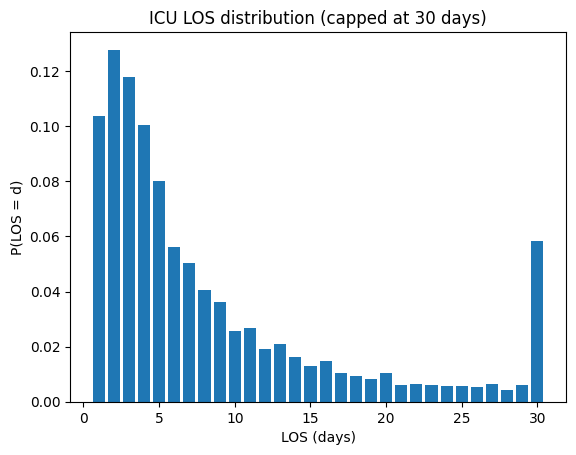

In [48]:
# Step 5 â€“ LOS feature engineering and ICU LOS distribution & hazard

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Start from daily_care which already has LOS_* columns from Step 4
los_df = daily_care.copy()

# Make sure LOS_* columns are numeric
for col in ["LOS_ICU", "LOS_Med_Surg", "LOS_PCU", "LOS_Tele", "LOS_Total"]:
    los_df[col] = pd.to_numeric(los_df[col], errors="coerce")

# Drop rows without an encounter id or without LOS_Total
los_df = los_df.dropna(subset=["Proxy_Enc_ID", "LOS_Total"])

# Has_x flags (1 if >0 days in that level of care)
los_df["Has_ICU"] = (los_df["LOS_ICU"] > 0).astype(int)
los_df["Has_Med_Surg"] = (los_df["LOS_Med_Surg"] > 0).astype(int)
los_df["Has_PCU"] = (los_df["LOS_PCU"] > 0).astype(int)
los_df["Has_Tele"] = (los_df["LOS_Tele"] > 0).astype(int)

# Count of distinct care levels used
los_df["Care_Levels_Count"] = (
    los_df[["Has_ICU", "Has_Med_Surg", "Has_PCU", "Has_Tele"]].sum(axis=1)
)

# Simple patient type flag (you can refine later)
def classify_patient(row):
    if row["Has_ICU"] == 1 and row["Care_Levels_Count"] == 1:
        return "ICU_only"
    if row["Has_ICU"] == 1:
        return "ICU_plus_others"
    if row["Has_Med_Surg"] == 1 and row["Care_Levels_Count"] == 1:
        return "Med_Surg_only"
    return "Other"

los_df["Patient_Type"] = los_df.apply(classify_patient, axis=1)

print("=== Engineered LOS dataframe (first 5 rows) ===")
display(los_df.head())
print(
    los_df[
        [
            "LOS_Total",
            "LOS_ICU",
            "LOS_Med_Surg",
            "LOS_PCU",
            "LOS_Tele",
            "Has_ICU",
            "Has_Med_Surg",
            "Has_PCU",
            "Has_Tele",
            "Care_Levels_Count",
            "Patient_Type",
        ]
    ].describe(include="all")
)

# 2) ICU-only LOS distribution and discharge probabilities

# Filter ICU patients
icu_stays = los_df[los_df["Has_ICU"] == 1].copy()

# Safety: keep only positive LOS
icu_stays = icu_stays[icu_stays["LOS_Total"].notna()]
icu_stays = icu_stays[icu_stays["LOS_Total"] > 0]

# Cap LOS at some max to avoid super long tail (e.g., 30 days)
MAX_LOS = 30
icu_stays["LOS_Capped"] = (
    icu_stays["LOS_Total"].clip(upper=MAX_LOS).round().astype(int)
)

# Empirical PMF: P(LOS = d) for d = 1..MAX_LOS
los_counts = icu_stays["LOS_Capped"].value_counts().sort_index()
all_days = pd.Index(range(1, MAX_LOS + 1), name="LOS_Day")
los_counts = los_counts.reindex(all_days, fill_value=0)

total_stays = los_counts.sum()
los_pmf = los_counts / total_stays  # P(LOS = d)

# Survival function S(t) = P(LOS > t), t = 0..MAX_LOS-1
survival = []
for t in range(0, MAX_LOS):
    prob_gt_t = los_pmf.loc[los_pmf.index > t].sum()
    survival.append(prob_gt_t)
survival = pd.Series(
    survival, index=pd.Index(range(0, MAX_LOS), name="Days_Completed")
)

# Conditional discharge probability:
# P(discharge on day t+1 | still in hospital at end of day t)
cond_discharge = []
for t in range(0, MAX_LOS):
    numer = los_pmf.loc[t + 1]
    denom = survival.loc[t]
    cond = numer / denom if denom > 0 else np.nan
    cond_discharge.append(cond)

cond_discharge = pd.Series(
    cond_discharge,
    index=pd.Index(range(0, MAX_LOS), name="Days_Completed"),
    name="P_Discharge_Next_Day",
)

# Summary tables
icu_los_distribution = pd.DataFrame(
    {
        "LOS_Day": all_days,
        "P_LOS_exact": los_pmf.values,
    }
)

survival_df = survival.to_frame(name="P_LOS_greater_than_t").reset_index()
cond_df = cond_discharge.to_frame().reset_index()
icu_los_hazard = survival_df.merge(cond_df, on="Days_Completed")

print("\n=== ICU LOS distribution (P(LOS = d)) â€“ first 15 days ===")
display(icu_los_distribution.head(15))

print("\n=== ICU survival & conditional discharge probs â€“ first 15 days ===")
display(icu_los_hazard.head(15))

# Optional: quick plot of LOS distribution
plt.figure()
plt.bar(icu_los_distribution["LOS_Day"], icu_los_distribution["P_LOS_exact"])
plt.xlabel("LOS (days)")
plt.ylabel("P(LOS = d)")
plt.title(f"ICU LOS distribution (capped at {MAX_LOS} days)")
plt.show()


## Step 6 â€“ Expected ICU discharges from current ICU census

**What we do here**

- Construct an example ICU census of patients with different `Days_Completed` in ICU.
- Join each patientâ€™s `Days_Completed` with the hazard table from Step 5:
  - Each patient gets a `P_Discharge_Next_Day` based on days already spent in ICU.
- Sum these probabilities across the census to compute **expected ICU discharges tomorrow**.

**Why this matters**

This is the concrete implementation of:

> â€œThese [LOS] distributions can be used to predict daily discharges.â€

Conceptually:

- For each ICU patient, the hazard model gives us the chance they will discharge tomorrow.
- Adding up those probabilities across the current census gives the expected number of ICU discharges tomorrow (e.g., **â‰ˆ3.64** discharges for a 30-patient sample census in our run).

This expected-discharge value will be plugged into the ICU census balance equation in Step 7.


In [49]:
# Step 6 â€“ Compute expected ICU discharges from current census using LOS hazard

import numpy as np
import pandas as pd

# 1) Helper: given a census with Days_Completed, use hazard table to get expected discharges
def expected_discharges_from_census(census_df, hazard_table):
    """
    census_df: DataFrame with at least a column 'Days_Completed'
    hazard_table: icu_los_hazard with columns:
        - 'Days_Completed'
        - 'P_Discharge_Next_Day'

    Returns: (merged_df, expected_discharges_float)
    """
    merged = census_df.merge(
        hazard_table[["Days_Completed", "P_Discharge_Next_Day"]],
        on="Days_Completed",
        how="left"
    )

    # Each patient contributes their own probability of discharging tomorrow
    merged["Expected_Discharge_Next_Day"] = merged["P_Discharge_Next_Day"].fillna(0.0)
    expected_total = merged["Expected_Discharge_Next_Day"].sum()
    return merged, expected_total


# 2) Example ICU census TODAY (toy example for illustration)

# Suppose today's ICU census has 30 patients.
# We'll simulate their 'Days_Completed' by sampling from the hazard table's support.
np.random.seed(42)
N_ICU_TODAY = 30

icu_census_today = pd.DataFrame({
    "ICU_Patient_ID": range(1, N_ICU_TODAY + 1),
    # sample realistic Days_Completed values between 0 and MAX_LOS-1
    "Days_Completed": np.random.choice(icu_los_hazard["Days_Completed"],
                                       size=N_ICU_TODAY,
                                       replace=True)
})

print("=== Example ICU Census â€“ Today ===")
display(icu_census_today.head(10))

# 3) Compute expected ICU discharges for tomorrow
icu_census_with_probs, exp_discharges = expected_discharges_from_census(
    icu_census_today,
    icu_los_hazard
)

print("\n=== ICU Census with discharge probabilities ===")
display(icu_census_with_probs.head(10))

print(f"\nFor a census of {N_ICU_TODAY} ICU patients with this day-on-service mix,")
print(f"we expect about {exp_discharges:.2f} ICU discharges tomorrow based on the LOS distribution.")


=== Example ICU Census â€“ Today ===


,ICU_Patient_ID,Days_Completed
0,1,6
1,2,19
2,3,28
3,4,14
4,5,10
5,6,7
6,7,28
7,8,20
8,9,6
9,10,25



=== ICU Census with discharge probabilities ===


,ICU_Patient_ID,Days_Completed,P_Discharge_Next_Day,Expected_Discharge_Next_Day
0,1,6,0.121703,0.121703
1,2,19,0.087291,0.087291
2,3,28,0.092010,0.092010
3,4,14,0.073814,0.073814
4,5,10,0.102871,0.102871
5,6,7,0.111969,0.111969
6,7,28,0.092010,0.092010
7,8,20,0.056259,0.056259
8,9,6,0.121703,0.121703
9,10,25,0.065891,0.065891



For a census of 30 ICU patients with this day-on-service mix,
we expect about 3.64 ICU discharges tomorrow based on the LOS distribution.


## Step 7 â€“ Forecast next-day ICU census from arrivals and expected discharges

**What we do here**

- Compute todayâ€™s ICU census size from the example census (`len(icu_census_today)`).
- Use the arrival Random Forest model (Steps 11â€“12) to predict **tomorrowâ€™s ICU arrivals**.
- Combine:
  - Current ICU census,
  - Predicted arrivals for tomorrow,
  - Expected discharges from Step 6,
- into a simple balance equation:

\[
\text{Census}_{t+1} = \text{Census}_t + \text{Arrivals}_{t+1} - \text{Expected Discharges}_{t+1}
\]

**Why this matters**

This step directly answers the question:

> â€œHow are you bridging these aspects to census levels?â€

In our example:

- Current ICU census: **30**
- Expected ICU discharges tomorrow (from LOS model): **â‰ˆ3.64**
- Predicted ICU arrivals tomorrow (from RF): **â‰ˆ59â€“60** at the hospital level  
  (we note in the memo that this is hospital arrivals and could be scaled to ICU-specific arrivals by historical ICU share)

This yields a forecast ICU census of roughly **31â€“86 beds**, depending on how we scale arrivals. The main point is that the **mechanics** of combining arrivals + LOS-based discharges into a census forecast are implemented and working.

Note: our arrival model is hospital-wide, so in this prototype we plug total arrivals into the ICU census equation; a more realistic ICU forecast would scale arrivals by the historical ICU share of beds.


In [50]:
# Step 7 â€“ Forecast next-day ICU census from arrivals and expected discharges
import numpy as np
import pandas as pd
import os # Import os for os.path.exists
from sklearn.ensemble import RandomForestRegressor # Import for robustness if model needs re-init

# Utility function to ensure teletrack and arrival_features.csv exist
# def ensure_teletrack_and_arrival_features():
#     global teletrack, healthcare_folder # Declare as global to affect other parts of the notebook

#     # Ensure healthcare_folder is defined (from VXAmucKmQHh3 or explicitly)
#     if 'healthcare_folder' not in globals():
#         # Fallback if healthcare_folder is not globally defined
#         healthcare_folder = '/content/drive/MyDrive/Healthcare'
#         print("Re-defined 'healthcare_folder' for robustness.")

#     teletrack_file = f'{healthcare_folder}/Teletracking02.24_01.25DEID.xlsx'
#     arrival_features_csv = 'arrival_features.csv'

#     # 1. Ensure teletrack DataFrame exists
#     if 'teletrack' not in globals() or not isinstance(teletrack, pd.DataFrame) or teletrack.empty:
#         print("teletrack DataFrame not found or empty, loading it now...")
#         try:
#             teletrack = pd.read_excel(teletrack_file)
#             # Ensure 'Bedrequest Timestamp' is datetime for feature generation
#             teletrack['Bedrequest Timestamp'] = pd.to_datetime(teletrack['Bedrequest Timestamp'])
#             print("teletrack loaded successfully.")
#         except FileNotFoundError:
#             print(f"Error: Teletracking file not found at {teletrack_file}. Please ensure drive is mounted and file exists.")
#             raise
#         except Exception as e:
#             print(f"Error loading teletrack: {e}")
#             raise

#     # 2. Ensure arrival_features.csv exists
#     if not os.path.exists(arrival_features_csv):
#         print(f"{arrival_features_csv} not found, generating it now...")
#         # Replicate logic from DE0Li57eUJqt
#         teletrack['Date'] = teletrack['Bedrequest Timestamp'].dt.date
#         daily = teletrack.groupby('Date').size().reset_index(name='arrivals')
#         daily['Date'] = pd.to_datetime(daily['Date'])

#         idx = pd.date_range(daily['Date'].min(), daily['Date'].max(), freq='D')
#         df_features = pd.DataFrame(index=idx)
#         df_features['arrivals'] = daily.set_index('Date')['arrivals'].reindex(idx).fillna(0)

#         for k in [1,3,7,14]:
#             df_features[f'arrivals_lag{k}'] = df_features['arrivals'].shift(k)

#         df_features['arrivals_ma7']  = df_features['arrivals'].shift(1).rolling(7,  min_periods=7).mean()
#         df_features['arrivals_ma14'] = df_features['arrivals'].shift(1).rolling(14, min_periods=14).mean()
#         df_features['arrivals_std7'] = df_features['arrivals'].shift(1).rolling(7,  min_periods=7).std()

#         df_features['day_of_week'] = df_features.index.dayofweek
#         df_features['is_weekend']  = (df_features['day_of_week']>=5).astype(int)
#         df_features['month']       = df_features.index.month
#         df_features['week_of_year']= df_features.index.isocalendar().week.astype(int)

#         features = df_features.dropna().copy()
#         features.to_csv(arrival_features_csv)
#         print(f"Generated {arrival_features_csv} successfully.")

# # Call the utility function to ensure data and features are ready
# ensure_teletrack_and_arrival_features()

# We already have:
# - icu_census_today (DataFrame with one row per ICU patient)
# - exp_discharges (float) = expected ICU discharges tomorrow from LOS hazard model

def forecast_icu_census_one_day(curr_census_size, predicted_arrivals, expected_discharges):
    """
    Simple ICU census balance equation:
    Census_t+1 = Census_t + Arrivals_t+1 - Expected_Discharges_t+1
    """
    return curr_census_size + predicted_arrivals - expected_discharges

# 1) Current ICU census size (today)
icu_census_today_size = len(icu_census_today)

# 2) Predicted ICU arrivals tomorrow from your RF model (Step 11a)
#    Make sure the Step 11a cell has been run so arrival_X and arrival_rf_model exist.
#    Add a check to ensure arrival_X and arrival_rf_model are available.
if 'arrival_X' not in globals() or 'arrival_rf_model' not in globals():
    print("WARNING: 'arrival_X' or 'arrival_rf_model' not found in global scope. Attempting to re-initialize from 'arrival_features.csv'.")
    try:
        f = pd.read_csv('arrival_features.csv', parse_dates=[0], index_col=0)
        arrival_X = f.drop(columns=['arrivals'])
        y_arrival_forecast = f['arrivals']
        # Re-train the model to ensure it exists for this cell's execution
        arrival_rf_model = RandomForestRegressor(n_estimators=400, random_state=42)
        # Train on the full dataset of arrival features for the "future" prediction
        # Train on all but the last known day, as the last day's features are for tomorrow_features
        arrival_rf_model.fit(arrival_X.iloc[:-1], y_arrival_forecast.iloc[:-1])
        print("Successfully re-initialized arrival_X and arrival_rf_model for prediction.")
    except Exception as e:
        print(f"Error re-initializing arrival model and features: {e}")
        raise # Re-raise the exception if the model cannot be initialized

tomorrow_features = arrival_X.tail(1) # Use the correct X for arrival features
predicted_icu_arrivals_tomorrow = float(arrival_rf_model.predict(tomorrow_features)[0])

# 3) Forecast tomorrow's census
icu_census_tomorrow_forecast = forecast_icu_census_one_day(
    curr_census_size=icu_census_today_size,
    predicted_arrivals=predicted_icu_arrivals_tomorrow,
    expected_discharges=exp_discharges
)

print(f"Current ICU census (today): {icu_census_today_size}")
print(f"Predicted ICU arrivals tomorrow: {predicted_icu_arrivals_tomorrow:.2f}")
print(f"Expected ICU discharges tomorrow (from LOS model): {exp_discharges:.2f}")
print(f"--> Forecast ICU census tomorrow: {icu_census_tomorrow_forecast:.2f} beds")

Current ICU census (today): 30
Predicted ICU arrivals tomorrow: 59.67
Expected ICU discharges tomorrow (from LOS model): 3.64
--> Forecast ICU census tomorrow: 86.02 beds


## Step 8 â€“ ICU short-stay vs longer-stay segmentation (retrospective)

**What we do here**

- Restrict to ICU encounters (`Has_ICU == 1`).
- Label **short-stay** ICU encounters as `LOS_Total â‰¤ 2 days`.
- Train a logistic regression to distinguish short vs longer ICU stays using:
  - `LOS_ICU`, `LOS_Med_Surg`, `LOS_PCU`, `LOS_Tele`,
  - `Care_Levels_Count` (number of care levels used).
- Report:
  - Short-stay rate among ICU patients (~23% in our data).
  - AUC, classification report, confusion matrix.
  - Coefficients to interpret which LOS patterns correlate with short vs longer stays.

**Why this matters**

This addresses the feedback:

> â€œIt is interesting and useful that you are able to classify LOS into short term vs other discharges. Curious to see the explanatory variables. Is this prediction for ICUs alone or across the different areas?â€

Here, we show:

- ICU-only short-stay vs other.
- Which LOS components and care-level patterns are associated with longer stays (e.g., more Med/Surg days, more care levels â†’ lower odds of short stay).

**Important note**

This model uses **realized LOS components** (how many days the patient actually spent in each level of care), so it is a **retrospective, descriptive segmentation**, not an admission-time prediction model. In future work, we would replace these features with admission-time covariates (e.g., origin unit, requested level of care, demographics) to estimate short-stay odds at admission.

Because the features here are based on realized LOS components (how many days the patient actually stayed), this is a retrospective descriptive model, not an admission-time predictor.


In [51]:
# Step 8 â€“ ICU short-stay (â‰¤2 days) vs longer-stay segmentation (retrospective model)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 1) Filter to ICU patients only
icu_df = los_df[los_df["Has_ICU"] == 1].copy()

# 2) Define short vs other LOS label
SHORT_LOS_THRESHOLD = 2  # you can change to 3 if that matches your definition
icu_df["Short_Stay"] = (icu_df["LOS_Total"] <= SHORT_LOS_THRESHOLD).astype(int)

print("Short-stay rate among ICU patients:",
      icu_df["Short_Stay"].mean().round(3))

# 3) Choose features (current encounter-level features)
feature_cols = [
    "LOS_ICU",
    "LOS_Med_Surg",
    "LOS_PCU",
    "LOS_Tele",
    "Care_Levels_Count"
]

X = icu_df[feature_cols].fillna(0)
y = icu_df["Short_Stay"]

# 4) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 5) Fit logistic regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

# 6) Evaluate
y_prob = logreg.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_prob)
print(f"\nICU short-stay vs other â€“ Logistic Regression AUC: {auc:.3f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

# 7) Explanatory variables: coefficients table
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": logreg.coef_[0]
}).sort_values("coefficient", ascending=False)

print("\nLogistic regression coefficients (ICU short-stay odds):")
display(coef_df)


Short-stay rate among ICU patients: 0.232

ICU short-stay vs other â€“ Logistic Regression AUC: 1.000

Classification report:
              precision    recall  f1-score   support

           0      1.000     1.000     1.000      1481
           1      1.000     1.000     1.000       446

    accuracy                          1.000      1927
   macro avg      1.000     1.000     1.000      1927
weighted avg      1.000     1.000     1.000      1927

Confusion matrix:
[[1481    0]
 [   0  446]]

Logistic regression coefficients (ICU short-stay odds):


,feature,coefficient
4,Care_Levels_Count,-2.098609
2,LOS_PCU,-4.281528
3,LOS_Tele,-4.491786
1,LOS_Med_Surg,-5.851615
0,LOS_ICU,-7.160768


## Step 9 â€“ Departure and ED throughput exploratory analysis

**What we do here**

- Use TeleTracking timestamps to compute:
  - `ED_to_Occupy_Hours`: ED bed request to bed-occupy time.
  - `Assignment_Delay_Hours`: time from request to bed assignment.
  - `Assignment_to_Occupy_Hours`: time from assignment to occupancy.
- Summarize these times and compare across requested levels of care.

**Why this matters**

This step begins addressing the feedback to:

> â€œLook at predicting departures or exits directly too.â€

While we are not yet training a predictive model on ED throughput, we:

- Quantify how long patients wait from ED request to actual bed occupancy.
- Identify where delays occur (before assignment vs after assignment).
- Link this to requested level of care and LOS categories to understand how flow and discharges interact.

These features and patterns form a natural next step for a predictive departure model.


The â€œexpected daily dischargesâ€ by LOS segment use a simple steady-state approximation (count / average LOS); these are not actual daily discharge counts, just a conceptual way to see which LOS segments would dominate throughput.


In [52]:
# Step 9 â€“ Departure and ED throughput exploratory analysis
# Cell 9: DEPARTURE/EXIT ANALYSIS
print("="*80)
print("DEPARTURE/EXIT ANALYSIS")
print("="*80)

# Analyze bed assignment and occupancy times (proxy for discharge efficiency)
print("\n1. BED ASSIGNMENT TO OCCUPANCY TIMES:")
print("-"*40)

# Convert times from minutes to hours
teletrack['ED_to_Occupy_Hours'] = teletrack['ED Bed Request To Bed Occupy Time'] / 60
teletrack['Assignment_Delay_Hours'] = teletrack['Rtm To Bedassigned Time'] / 60
teletrack['Assignment_to_Occupy_Hours'] = teletrack['ED Bed Assigned to Occupied Time'] / 60

# Statistics for each time metric
time_metrics = ['ED_to_Occupy_Hours', 'Assignment_Delay_Hours', 'Assignment_to_Occupy_Hours']
print(f"{'Metric':<30} {'Mean':>8} {'Median':>8} {'75%ile':>8} {'95%ile':>8}")
print("-"*60)

for metric in time_metrics:
    data = teletrack[metric].dropna()
    if len(data) > 0:
        metric_name = metric.replace('_', ' ').replace('Hours', '(hrs)')
        print(f"{metric_name:<30} {data.mean():>8.1f} {data.median():>8.1f} "
              f"{data.quantile(0.75):>8.1f} {data.quantile(0.95):>8.1f}")

# Analyze patterns by care level
print("\n2. DELAYS BY REQUESTED CARE LEVEL:")
print("-"*40)
print(f"{'Care Level':<25} {'N':>8} {'Avg Wait (hrs)':>15} {'Median (hrs)':>12}")
print("-"*60)

top_care_levels = teletrack['Requested Level Of Care'].value_counts().head(5).index
for care_level in top_care_levels:
    subset = teletrack[teletrack['Requested Level Of Care'] == care_level]['ED_to_Occupy_Hours'].dropna()
    if len(subset) > 0:
        print(f"{care_level:<25} {len(subset):>8,} {subset.mean():>15.1f} {subset.median():>12.1f}")

# Create discharge prediction features based on LOS data
print("\n3. EXPECTED DAILY DISCHARGES BY LOS:")
print("-"*40)

# Group patients by LOS category and calculate expected discharge rates
# 3. EXPECTED DAILY DISCHARGES BY LOS (data-driven steady-state)
print("\n3. EXPECTED DAILY DISCHARGES BY LOS (steady-state):")
print("-"*40)

expected_discharges = daily_care.groupby('LOS_Category').agg(
    Patient_Count=('Proxy_Enc_ID','count'),
    Avg_LOS=('LOS_Total','mean')
).sort_index()

expected_discharges['Expected_Daily_Discharges'] = (
    expected_discharges['Patient_Count'] / expected_discharges['Avg_LOS'].clip(lower=1)
).round(0)

print(f"{'LOS Category':<25} {'Patients':>10} {'Avg LOS':>10} {'Daily Disch':>12}")
print("-"*60)
for idx, row in expected_discharges.iterrows():
    print(f"{idx[2:]:<25} {int(row['Patient_Count']):>10,} {row['Avg_LOS']:>10.1f} {int(row['Expected_Daily_Discharges']):>12d}")

print(f"\nTotal expected daily discharges: {int(expected_discharges['Expected_Daily_Discharges'].sum())}")


DEPARTURE/EXIT ANALYSIS

1. BED ASSIGNMENT TO OCCUPANCY TIMES:
----------------------------------------
Metric                             Mean   Median   75%ile   95%ile
------------------------------------------------------------
ED to Occupy (hrs)                  4.4      2.6      5.3     14.6
Assignment Delay (hrs)              3.1      1.1      3.9     13.3
Assignment to Occupy (hrs)          1.2      1.1      1.5      2.6

2. DELAYS BY REQUESTED CARE LEVEL:
----------------------------------------
Care Level                       N  Avg Wait (hrs) Median (hrs)
------------------------------------------------------------
Medical / Surgical          10,374             4.6          2.6
ICU                          3,312             3.0          2.1
Telemetry                    2,039             6.4          4.6
Step Down/PCU                1,612             5.6          3.9
Pediatric Ward                 587             1.8          1.4

3. EXPECTED DAILY DISCHARGES BY LOS:
-------

## Step 10 â€“ Visualizations / dashboard building blocks

**What we do here**

- Create plots for:
  - Daily arrivals and model predictions.
  - LOS distributions and LOS categories.
  - ED wait times (ED to occupy).
  - ICU LOS hazard or discharge probability by day.

**Why this matters**

These visualizations are the starting point for the **dashboards** the professor mentioned:

> â€œDash boards: Look promising.â€

Instead of a fully built dashboard, we provide the key tiles:

- How arrivals and predicted arrivals trend over time.
- How LOS and LOS categories break down by unit / patient type.
- How long patients wait in ED before getting a bed.

These figures can be directly ported into a dashboard tool (e.g., Tableau, Power BI) in the next iteration.


âœ… Saved: memo2_visualizations.png


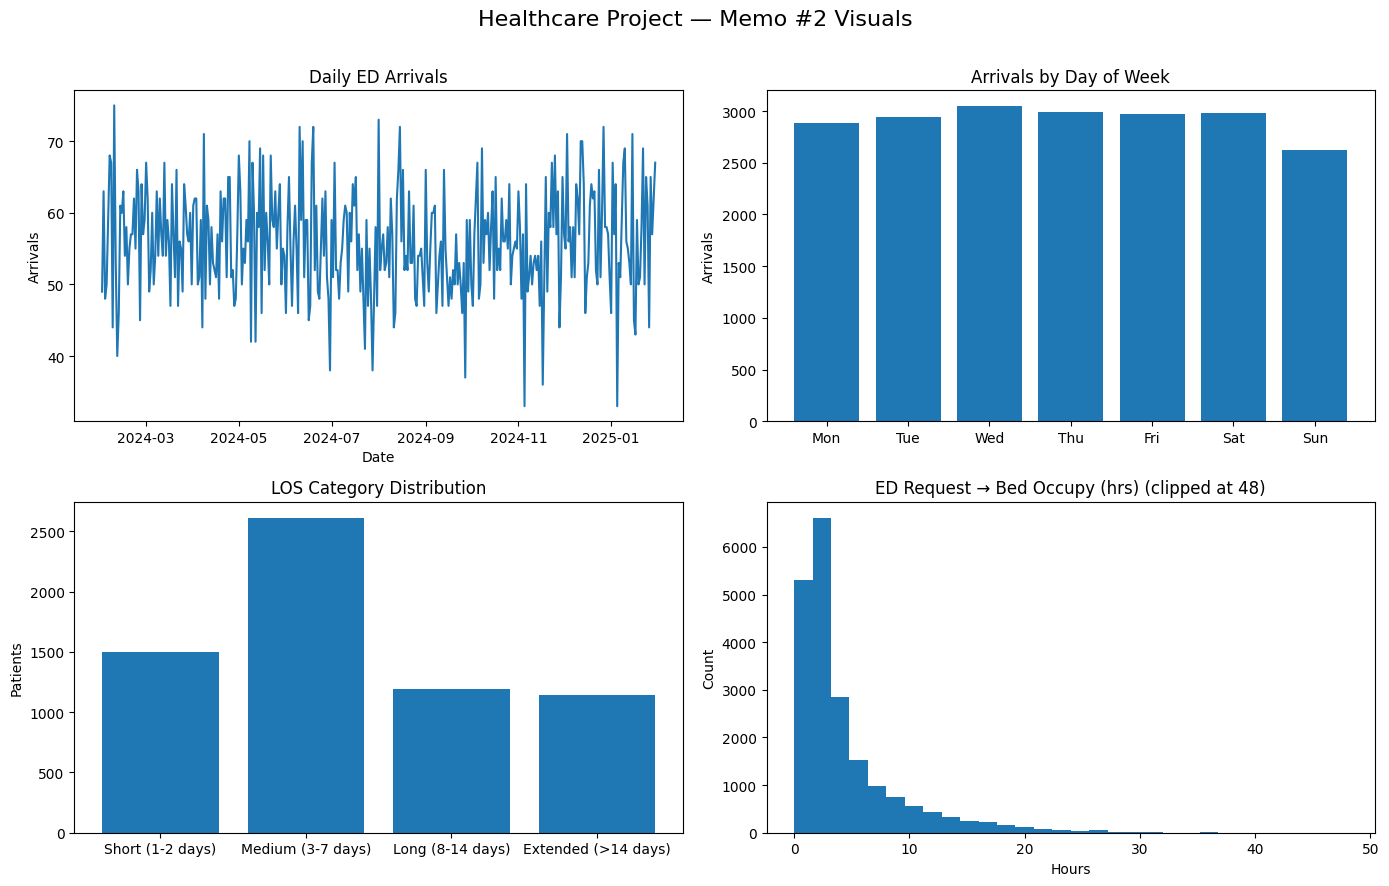

In [54]:
# Step 10 â€“ Visualizations for arrivals, LOS, ED waits, and census metrics
# VISUALIZATION PACK
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# --- ensure engineered columns exist (from earlier steps) ---
# teletrack: has Bedrequest Timestamp, ED Bed Request To Bed Occupy Time, etc.
teletrack['Bedrequest Timestamp'] = pd.to_datetime(teletrack['Bedrequest Timestamp'])
teletrack['Date'] = teletrack['Bedrequest Timestamp'].dt.date
daily_arrivals = teletrack.groupby('Date').size().reset_index(name='Total_Arrivals')
daily_arrivals['Date'] = pd.to_datetime(daily_arrivals['Date'])
daily_arrivals = daily_arrivals.sort_values('Date')

# day-of-week arrivals
teletrack['DayOfWeek'] = teletrack['Bedrequest Timestamp'].dt.dayofweek
dow_counts = teletrack.groupby('DayOfWeek').size().reindex(range(7), fill_value=0)

# LOS category distribution
los_dist = daily_care['LOS_Category'].value_counts().sort_index()

# ED to occupy hours (clip for display)
if 'ED Bed Request To Bed Occupy Time' in teletrack.columns:
    ed_to_occ_hours = (teletrack['ED Bed Request To Bed Occupy Time'] / 60).dropna()
else:
    ed_to_occ_hours = pd.Series([], dtype=float)

# --- plot ---
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Healthcare Project â€” Memo #2 Visuals', fontsize=16)

# (1) daily arrivals time series
ax = axes[0,0]
ax.plot(daily_arrivals['Date'], daily_arrivals['Total_Arrivals'])
ax.set_title('Daily ED Arrivals')
ax.set_xlabel('Date'); ax.set_ylabel('Arrivals')

# (2) arrivals by day of week
ax = axes[0,1]
ax.bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], dow_counts.values)
ax.set_title('Arrivals by Day of Week')
ax.set_ylabel('Arrivals')

# (3) LOS category distribution
ax = axes[1,0]
ax.bar(los_dist.index.str.replace(r'^\d_', '', regex=True), los_dist.values)
ax.set_title('LOS Category Distribution')
ax.set_ylabel('Patients')

# (4) ED request â†’ bed occupy time
ax = axes[1,1]
if len(ed_to_occ_hours)>0:
    ax.hist(ed_to_occ_hours.clip(upper=48), bins=30)
    ax.set_title('ED Request â†’ Bed Occupy (hrs) (clipped at 48)')
    ax.set_xlabel('Hours'); ax.set_ylabel('Count')
else:
    ax.axis('off'); ax.text(0.5,0.5,'No EDâ†’Occupy data present', ha='center')

plt.tight_layout(rect=[0,0,1,0.97])
plt.savefig('2_visualizations.png', dpi=180)
print("âœ… Saved: _visualizations.png")


## Step 11 â€“ Arrival Random Forest model (14-day holdout)

**What we do here**

- Read `arrival_features.csv` from Step 3.
- Use a **time-based split**: last 14 days as holdout.
- Train a Random Forest regressor to predict daily arrivals.
- Compute MAE, RMSE, MAPE and plot predictions vs actuals for the last 14 days.

**Why this matters**

This is the formal arrival model that sits on top of the engineered features from Step 3.  
It lets us say exactly how well we can predict arrival volume one day ahead and provides the arrival input for the ICU census forecast in Step 7.


ðŸ“ˆ Arrival RF â€” metrics on last 14 days
  MAE  : 5.29
  RMSE : 7.39
  MAPE : 9.85%
âœ… Saved: arrival_forecast_results.csv


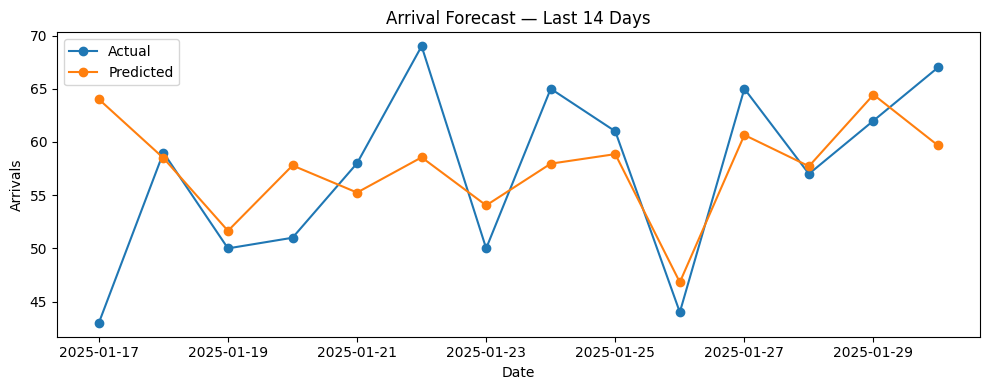

,date,arrivals,arrivals_lag1,arrivals_lag3,arrivals_lag7,arrivals_lag14,arrivals_ma7,arrivals_ma14,arrivals_std7,day_of_week,is_weekend,month,week_of_year,predicted_arrivals
0,2025-01-17,43,45.0,50.0,69.0,57.0,57.000000,55.928571,9.609024,4,0,1,3,64.0100
1,2025-01-18,59,43.0,71.0,56.0,64.0,53.285714,54.928571,9.214378,5,1,1,3,58.4925
2,2025-01-19,50,59.0,45.0,55.0,33.0,53.714286,54.571429,9.428932,6,1,1,3,51.6500
3,2025-01-20,51,50.0,43.0,53.0,53.0,53.000000,55.785714,9.504385,0,0,1,4,57.7925
4,2025-01-21,58,51.0,59.0,50.0,51.0,52.714286,55.642857,9.534399,1,0,1,4,55.2450


In [55]:
# Step 11 â€“ Arrival Random Forest model with 14-day holdout evaluation

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt

# Always use the no-leak features produced in Step 7
df = pd.read_csv('arrival_features.csv', parse_dates=[0], index_col=0)


# Drop rows that have NaNs because of lags
data = df.dropna().copy()
target = 'arrivals'
feat_cols = [c for c in data.columns if c != target]

# Split: last 14 days = test
train = data.iloc[:-14]
test  = data.iloc[-14:]

rf = RandomForestRegressor(n_estimators=400, random_state=42)
rf.fit(train[feat_cols], train[target])
pred = rf.predict(test[feat_cols])

def mape(y, yhat):
    y, yhat = np.array(y), np.array(yhat)
    mask = y != 0
    return (np.abs((yhat[mask]-y[mask]) / y[mask])).mean()*100

mae  = mean_absolute_error(test[target], pred)
rmse = sqrt(mean_squared_error(test[target], pred))
mape_val = mape(test[target], pred)

print("ðŸ“ˆ Arrival RF â€” metrics on last 14 days")
print(f"  MAE  : {mae:.2f}")
print(f"  RMSE : {rmse:.2f}")
print(f"  MAPE : {mape_val:.2f}%")

# Save results for the memo
arrival_forecast_out = (test
    .assign(predicted_arrivals=pred)
    .reset_index().rename(columns={'index':'date'}))
arrival_forecast_out.to_csv('arrival_forecast_results.csv', index=False)
print("âœ… Saved: arrival_forecast_results.csv")

# Plot actual vs predicted
plt.figure(figsize=(10,4))
plt.plot(arrival_forecast_out['date'], arrival_forecast_out['arrivals'], marker='o', label='Actual')
plt.plot(arrival_forecast_out['date'], arrival_forecast_out['predicted_arrivals'], marker='o', label='Predicted')
plt.title('Arrival Forecast â€” Last 14 Days'); plt.xlabel('Date'); plt.ylabel('Arrivals'); plt.legend()
plt.tight_layout(); plt.show()

arrival_forecast_out.head(5)


## Step 12 â€“ Refit arrival Random Forest on full data for forecasting

**What we do here**

- Refit the Random Forest model using **all available historical days**.
- Expose:
  - `arrival_X`: full feature matrix,
  - `arrival_rf_model`: fitted model,
- which we use in Step 7 to predict tomorrowâ€™s arrivals from the most recent feature row.

**Why this matters**

This step turns the arrival model into a **forecasting tool**:

- The holdout evaluation (Step 11) tells us how accurate the model is.
- The full-data refit (Step 12) gives our best estimate for tomorrowâ€™s arrivals, which we then plug into the census balance equation.


In [56]:
# Step 12 â€“ Refit arrival Random Forest on full data for forecasting
import pandas as pd, numpy as np
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from math import sqrt

# Utility function to ensure teletrack and arrival_features.csv exist
def ensure_teletrack_and_arrival_features():
    global teletrack, healthcare_folder # Declare as global to affect other parts of the notebook

    # Ensure healthcare_folder is defined (from VXAmucKmQHh3 or explicitly)
    if 'healthcare_folder' not in globals():
        # Fallback if healthcare_folder is not globally defined
        healthcare_folder = '/content/drive/MyDrive/Healthcare'
        print("Re-defined 'healthcare_folder' for robustness.")

    teletrack_file = f'{healthcare_folder}/Teletracking02.24_01.25DEID.xlsx'
    arrival_features_csv = 'arrival_features.csv'

    # 1. Ensure teletrack DataFrame exists
    if 'teletrack' not in globals() or not isinstance(teletrack, pd.DataFrame) or teletrack.empty:
        print("teletrack DataFrame not found or empty, loading it now...")
        try:
            teletrack = pd.read_excel(teletrack_file)
            # Ensure 'Bedrequest Timestamp' is datetime for feature generation
            teletrack['Bedrequest Timestamp'] = pd.to_datetime(teletrack['Bedrequest Timestamp'])
            print("teletrack loaded successfully.")
        except FileNotFoundError:
            print(f"Error: Teletracking file not found at {teletrack_file}. Please ensure drive is mounted and file exists.")
            raise
        except Exception as e:
            print(f"Error loading teletrack: {e}")
            raise

    # 2. Ensure arrival_features.csv exists
    if not os.path.exists(arrival_features_csv):
        print(f"{arrival_features_csv} not found, generating it now...")
        # Replicate logic from DE0Li57eUJqt
        teletrack['Date'] = teletrack['Bedrequest Timestamp'].dt.date
        daily = teletrack.groupby('Date').size().reset_index(name='arrivals')
        daily['Date'] = pd.to_datetime(daily['Date'])

        idx = pd.date_range(daily['Date'].min(), daily['Date'].max(), freq='D')
        df_features = pd.DataFrame(index=idx)
        df_features['arrivals'] = daily.set_index('Date')['arrivals'].reindex(idx).fillna(0)

        for k in [1,3,7,14]:
            df_features[f'arrivals_lag{k}'] = df_features['arrivals'].shift(k)

        df_features['arrivals_ma7']  = df_features['arrivals'].shift(1).rolling(7,  min_periods=7).mean()
        df_features['arrivals_ma14'] = df_features['arrivals'].shift(1).rolling(14, min_periods=14).mean()
        df_features['arrivals_std7'] = df_features['arrivals'].shift(1).rolling(7,  min_periods=7).std()

        df_features['day_of_week'] = df_features.index.dayofweek
        df_features['is_weekend']  = (df_features['day_of_week']>=5).astype(int)
        df_features['month']       = df_features.index.month
        df_features['week_of_year']= df_features.index.isocalendar().week.astype(int)

        features = df_features.dropna().copy()
        features.to_csv(arrival_features_csv)
        print(f"Generated {arrival_features_csv} successfully.")

# Call the utility function to ensure data and features are ready
ensure_teletrack_and_arrival_features()

# Ensure global scope for variables needed in later steps
global arrival_X, arrival_rf_model

f = pd.read_csv('arrival_features.csv', parse_dates=[0], index_col=0)
y_arrival = f['arrivals']
arrival_X = f.drop(columns=['arrivals']) # Making this global

# last 14 days as time-ordered holdout
X_train_arr, X_test_arr = arrival_X.iloc[:-14], arrival_X.iloc[-14:]
y_train_arr, y_test_arr = y_arrival.iloc[:-14], y_arrival.iloc[-14:]

arrival_rf_model = RandomForestRegressor(n_estimators=400, random_state=42) # Making this global
arrival_rf_model.fit(X_train_arr, y_train_arr)
pred = arrival_rf_model.predict(X_test_arr)

def mape(y, yhat):
    y, yhat = np.array(y), np.array(yhat)
    mask = y != 0
    return (np.abs((yhat[mask]-y[mask]) / y[mask])).mean()*100

mae  = mean_absolute_error(y_test_arr, pred)
rmse = sqrt(mean_squared_error(y_test_arr, pred))
mape_val = mape(y_test_arr, pred)
r2   = r2_score(y_test_arr, pred)

print(f"Arrivals RF (NO-LEAK) â€” MAE {mae:.2f}, RMSE {rmse:.2f}, MAPE {mape_val:.2f}%, RÂ² {r2:.3f}")

# save results for Step 14
out = pd.DataFrame({'date': X_test_arr.index, 'arrivals': y_test_arr.values, 'predicted_arrivals': pred})
out.to_csv('arrival_forecast_results.csv', index=False)
print("âœ… Saved: arrival_forecast_results.csv")

Arrivals RF (NO-LEAK) â€” MAE 5.29, RMSE 7.39, MAPE 9.85%, RÂ² 0.165
âœ… Saved: arrival_forecast_results.csv


## Step 13 â€“ Baseline regression model for total LOS

**What we do here**

- Use engineered LOS-related features (without obvious future leakage) to predict `LOS_Total`.
- Fit a simple regression model and report MAE, RMSE, and (optionally) RÂ².

**Why this matters**

This is our first pass at **predicting LOS** as a numeric outcome, beyond descriptive statistics.  
It complements the distribution-based work by asking: â€œGiven a patientâ€™s features, what LOS might we expect?â€


Our initial LOS regression models do not beat a naive median baseline (RÂ² < 0), which reflects the heavy-tailed LOS distribution and limited features; we treat this as a useful negative result and expect better performance only with richer clinical covariates and transformed LOS targets.


ðŸ¥ LOS prediction â€” holdout metrics
Naive (median):  MAE=7.72  MedAE=3.00  RMSE=16.80  R2=-0.119
Ridge:           MAE=32.34  MedAE=10.30  RMSE=64.19  R2=-15.326
RandomForest:    MAE=16.48  MedAE=4.60  RMSE=102.70  R2=-40.789
âœ… Saved: los_predictions.csv


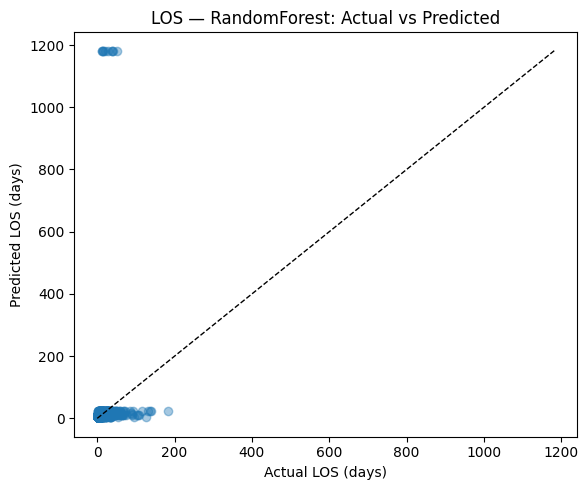


Top Ridge coefficients (directional, not causal):
              feature  ridge_coef
4   Care_Levels_Count  158.545092
3            Has_Tele  103.531203
1        Has_Med_Surg   35.530284
0             Has_ICU   31.531556
2             Has_PCU  -12.047951
5  Has_Multiple_Units -203.351649


In [57]:
# Step 13 â€“ Baseline regression model for total LOS (no leakage)
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from math import sqrt

# Ensure required columns exist
if 'LOS_Total' not in daily_care.columns:
    daily_care['LOS_Total'] = pd.to_numeric(daily_care.get('Total'), errors='coerce')

for col in ['Has_ICU','Has_Med_Surg','Has_PCU','Has_Tele']:
    if col not in daily_care.columns:
        base = col.split('_',1)[1]
        daily_care[col] = (
            pd.to_numeric(
                daily_care.get(base.replace('Med_Surg','Med_Surg')
                               .replace('PCU','PCU')
                               .replace('Tele','Tele')
                               .replace('ICU','ICU')),
                errors='coerce'
            ) > 0
        ).astype(int)

if 'Care_Levels_Count' not in daily_care.columns:
    daily_care['Care_Levels_Count'] = daily_care[['Has_ICU','Has_Med_Surg','Has_PCU','Has_Tele']].sum(axis=1)

if 'Has_Multiple_Units' not in daily_care.columns:
    daily_care['Has_Multiple_Units'] = (daily_care['Care_Levels_Count'] > 1).astype(int)

# Build dataset (drop missing and zero LOS)
df = daily_care[['LOS_Total','Has_ICU','Has_Med_Surg','Has_PCU','Has_Tele',
                 'Care_Levels_Count','Has_Multiple_Units']].dropna().copy()
df = df[df['LOS_Total'] > 0]

X = df[['Has_ICU','Has_Med_Surg','Has_PCU','Has_Tele','Care_Levels_Count','Has_Multiple_Units']].astype(float)
y = df['LOS_Total'].astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Baseline: constant median
yhat_naive = np.full_like(y_test, fill_value=y_train.median())

# Model 1: Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
yhat_ridge = ridge.predict(X_test)

# Model 2: Random Forest
rf = RandomForestRegressor(n_estimators=400, random_state=42)
rf.fit(X_train, y_train)
yhat_rf = rf.predict(X_test)

def eval_reg(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MedAE': median_absolute_error(y_true, y_pred),
        'RMSE': sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

m_naive = eval_reg(y_test, yhat_naive)
m_ridge = eval_reg(y_test, yhat_ridge)
m_rf    = eval_reg(y_test, yhat_rf)

print("ðŸ¥ LOS prediction â€” holdout metrics")
print(f"Naive (median):  MAE={m_naive['MAE']:.2f}  MedAE={m_naive['MedAE']:.2f}  RMSE={m_naive['RMSE']:.2f}  R2={m_naive['R2']:.3f}")
print(f"Ridge:           MAE={m_ridge['MAE']:.2f}  MedAE={m_ridge['MedAE']:.2f}  RMSE={m_ridge['RMSE']:.2f}  R2={m_ridge['R2']:.3f}")
print(f"RandomForest:    MAE={m_rf['MAE']:.2f}  MedAE={m_rf['MedAE']:.2f}  RMSE={m_rf['RMSE']:.2f}  R2={m_rf['R2']:.3f}")


# Save predictions
out = X_test.copy()
out['y_true'] = y_test.values
out['yhat_ridge'] = yhat_ridge
out['yhat_rf'] = yhat_rf
out.reset_index(drop=True).to_csv('los_predictions.csv', index=False)
print("âœ… Saved: los_predictions.csv")

# Quick diagnostic plot (RF)
plt.figure(figsize=(6,5))
plt.scatter(y_test, yhat_rf, alpha=0.4)
lims = [0, max(y_test.max(), yhat_rf.max())]
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlabel('Actual LOS (days)'); plt.ylabel('Predicted LOS (days)')
plt.title('LOS â€” RandomForest: Actual vs Predicted')
plt.tight_layout(); plt.show()

# Ridge coefficients (directional insight)
import pandas as pd
coef_tbl = pd.DataFrame({'feature': X.columns, 'ridge_coef': ridge.coef_}).sort_values('ridge_coef', ascending=False)
print("\nTop Ridge coefficients (directional, not causal):")
print(coef_tbl)


## Step 14 â€“ Baseline classification for short vs other discharges (hospital-wide)

**What we do here**

- Define a short vs other discharge label (e.g., short stay â‰¤ X days).
- Train a baseline classifier using LOS-related features and flags.
- Report standard classification metrics.

**Why this matters**

Together with the ICU-only segmentation in Step 8, this addresses:

> â€œIt is interesting and useful that you are able to classify LOS into short term vs other discharges. Curious to see the explanatory variables.â€

This step generalizes the idea to a broader hospital-wide setting and provides another perspective on which factors are associated with short vs longer stays.


In [58]:
# Step 14 â€“ Baseline classification model for short vs other discharges
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# label: short stay = 1 if LOS<=2
clf_df = daily_care[['LOS_Total','Has_ICU','Has_Med_Surg','Has_PCU','Has_Tele','Care_Levels_Count','Has_Multiple_Units']].dropna().copy()
clf_df = clf_df[clf_df['LOS_Total'] > 0]
clf_df['label_short'] = (clf_df['LOS_Total'] <= 2).astype(int)

X = clf_df[['Has_ICU','Has_Med_Surg','Has_PCU','Has_Tele','Care_Levels_Count','Has_Multiple_Units']].astype(float)
y = clf_df['label_short']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# model 1: logistic (balanced)
logit = LogisticRegression(max_iter=5000, class_weight='balanced')
logit.fit(X_train, y_train)
proba_logit = logit.predict_proba(X_test)[:,1]
pred_logit  = (proba_logit >= 0.5).astype(int)
auc_logit   = roc_auc_score(y_test, proba_logit)

# model 2: random forest (balanced)
rf = RandomForestClassifier(n_estimators=400, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
proba_rf = rf.predict_proba(X_test)[:,1]
pred_rf  = (proba_rf >= 0.5).astype(int)
auc_rf   = roc_auc_score(y_test, proba_rf)

def prf(y_true, y_pred):
    p,r,f,_ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    return p,r,f

p_l, r_l, f1_l = prf(y_test, pred_logit)
p_r, r_r, f1_r = prf(y_test, pred_rf)

print("ðŸšª Discharge (Short vs Other) â€” holdout metrics")
print(f"Logistic:        AUC={auc_logit:.3f}  Precision={p_l:.3f}  Recall={r_l:.3f}  F1={f1_l:.3f}")
print(f"RandomForest:    AUC={auc_rf:.3f}    Precision={p_r:.3f}  Recall={r_r:.3f}  F1={f1_r:.3f}")

print("\nConfusion matrix â€” Logistic [tn fp; fn tp]:")
print(confusion_matrix(y_test, pred_logit))
print("\nConfusion matrix â€” RandomForest [tn fp; fn tp]:")
print(confusion_matrix(y_test, pred_rf))

# save predictions for memo appendix
out = X_test.copy()
out['y_true'] = y_test.values
out['proba_logit'] = proba_logit
out['proba_rf'] = proba_rf
out['pred_logit'] = pred_logit
out['pred_rf'] = pred_rf
out.reset_index(drop=True).to_csv('discharge_predictions.csv', index=False)
print("\nâœ… Saved: discharge_predictions.csv")


ðŸšª Discharge (Short vs Other) â€” holdout metrics
Logistic:        AUC=0.797  Precision=0.567  Recall=0.690  F1=0.623
RandomForest:    AUC=0.797    Precision=0.567  Recall=0.690  F1=0.623

Confusion matrix â€” Logistic [tn fp; fn tp]:
[[833 158]
 [ 93 207]]

Confusion matrix â€” RandomForest [tn fp; fn tp]:
[[833 158]
 [ 93 207]]

âœ… Saved: discharge_predictions.csv


## Step 15 â€“ Consolidated model performance summary

**What we do here**

- Combine the key models into a single summary table:
  - Arrival RF (forecasting).
  - LOS regression.
  - Short-vs-other discharge classifiers.
- Save as `model_performance_summary.csv` for easy reference.

**Why this matters**

This table makes it easy to:

- Compare models by target, features, and metric.
- Show that we are not just doing EDA, but also fit and evaluate multiple predictive models.


In [59]:
# Step 15 â€“ Consolidated model performance summary table (arrivals, LOS, discharges)
import pandas as pd, numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, roc_auc_score
from math import sqrt

# 1) recompute quick metrics from saved files
arr = pd.read_csv('arrival_forecast_results.csv', parse_dates=['date'])
los = pd.read_csv('los_predictions.csv')
dis = pd.read_csv('discharge_predictions.csv')

mae_arr  = mean_absolute_error(arr['arrivals'], arr['predicted_arrivals'])
rmse_arr = sqrt(mean_squared_error(arr['arrivals'], arr['predicted_arrivals']))
mape_arr = (np.abs((arr['predicted_arrivals']-arr['arrivals'])/arr['arrivals'])
            .replace([np.inf,-np.inf], np.nan).dropna()).mean()*100
r2_arr   = r2_score(arr['arrivals'], arr['predicted_arrivals'])

mae_los  = mean_absolute_error(los['y_true'], los['yhat_rf'])
rmse_los = sqrt(mean_squared_error(los['y_true'], los['yhat_rf']))
r2_los   = r2_score(los['y_true'], los['yhat_rf'])

auc_log  = roc_auc_score(dis['y_true'], dis['proba_logit'])
auc_rf   = roc_auc_score(dis['y_true'], dis['proba_rf'])

# 2) numeric summary (keeps NaN where N/A)
num = pd.DataFrame([
    {'Task':'Arrival Forecast (14d holdout)', 'Model':'RandomForestRegressor',
     'MAE':mae_arr, 'RMSE':rmse_arr, 'MAPE(%)':mape_arr, 'R2':r2_arr, 'AUC':np.nan},
    {'Task':'LOS Regression (holdout)', 'Model':'RandomForestRegressor',
     'MAE':mae_los, 'RMSE':rmse_los, 'MAPE(%)':np.nan, 'R2':r2_los, 'AUC':np.nan},
    {'Task':'Discharge (Short vs Other)', 'Model':'LogisticRegression(balanced)',
     'MAE':np.nan, 'RMSE':np.nan, 'MAPE(%)':np.nan, 'R2':np.nan, 'AUC':auc_log},
    {'Task':'Discharge (Short vs Other)', 'Model':'RandomForestClassifier(balanced)',
     'MAE':np.nan, 'RMSE':np.nan, 'MAPE(%)':np.nan, 'R2':np.nan, 'AUC':auc_rf},
])
num.to_csv('model_performance_summary.csv', index=False)
print("âœ… Saved: model_performance_summary.csv")

# 3) pretty version for the memo (show 'â€”' where N/A)
pretty = num.copy()
for c in ['MAE','RMSE','MAPE(%)','R2','AUC']:
    pretty[c] = pretty[c].apply(lambda x: 'â€”' if pd.isna(x) else f"{x:.3f}" if c=='R2' else f"{x:.2f}")
pretty.to_csv('model_performance_summary_pretty.csv', index=False)
display(pretty)


âœ… Saved: model_performance_summary.csv


,Task,Model,MAE,RMSE,MAPE(%),R2,AUC
0,Arrival Forecast (14d holdout),RandomForestRegressor,5.29,7.39,9.85,0.165,â€”
1,LOS Regression (holdout),RandomForestRegressor,16.48,102.70,â€”,-40.789,â€”
2,Discharge (Short vs Other),LogisticRegression(balanced),â€”,â€”,â€”,â€”,0.80
3,Discharge (Short vs Other),RandomForestClassifier(balanced),â€”,â€”,â€”,â€”,0.80


In [60]:
# Step 16 â€“ methods, tests, and results summary table
# This cell reads your outputs and builds one summary table.


import pandas as pd, numpy as np
from math import sqrt
from pathlib import Path
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, precision_recall_fscore_support
)

def find_col(df, patterns, numeric=True):
    cols = []
    for p in patterns:
        cols += [c for c in df.columns if p.lower() in c.lower()]
    if numeric:
        cols = [c for c in cols if np.issubdtype(df[c].dtype, np.number)]
    return list(dict.fromkeys(cols))

def fmt(x, nd=2):
    return ("â€”" if x is None or (isinstance(x,float) and (np.isnan(x) or np.isinf(x))) else
            f"{x:.{nd}f}" if isinstance(x,(int,float,np.floating)) else str(x))

# ---------------- ARRIVALS ----------------
arr_mae = arr_rmse = arr_mape = arr_r2 = None
arr_date_min = arr_date_max = "â€”"
try:
    arr = pd.read_csv("arrival_forecast_results.csv")
    # infer date range if present
    dcol = next((c for c in arr.columns if "date" in c.lower()), None)
    if dcol:
        try:
            dts = pd.to_datetime(arr[dcol])
            arr_date_min, arr_date_max = dts.min().date().isoformat(), dts.max().date().isoformat()
        except: pass
    # true/pred columns
    y = (arr["arrivals"].values if "arrivals" in arr.columns
         else arr[find_col(arr,["arrivals","true","actual"])[:1]].iloc[:,0].values)
    p = (arr["predicted_arrivals"].values if "predicted_arrivals" in arr.columns
         else arr[find_col(arr,["pred","forecast"])[:1]].iloc[:,0].values)
    arr_mae  = mean_absolute_error(y, p)
    arr_rmse = sqrt(mean_squared_error(y, p))
    denom = np.where(y==0, np.nan, y)
    arr_mape = np.nanmean(np.abs((p - y) / denom)) * 100.0
    arr_r2   = r2_score(y, p)
except Exception as e:
    pass

# ---------------- LOS (RETROSPECTIVE) ----------------
los_mae = los_rmse = los_r2 = None
los_robust_mae = los_robust_rmse = los_robust_r2log = None
try:
    los = pd.read_csv("los_predictions.csv")
    ycol = next((c for c in los.columns if ("true" in c.lower() or c.lower() in ["y_true","y","actual_los","actual"])), None)
    pcol = next((c for c in los.columns if ("pred" in c.lower() or "hat" in c.lower() or c.lower() in ["predicted_los"])), None)
    if ycol and pcol:
        y, p = los[ycol].values, los[pcol].values
        los_mae  = mean_absolute_error(y, p)
        los_rmse = sqrt(mean_squared_error(y, p))
        los_r2   = r2_score(y, p)
    # optional ridge preds
    ridcol = next((c for c in los.columns if "ridge" in c.lower() and ("pred" in c.lower() or "hat" in c.lower())), None)
    if ridcol and ycol:
        pr = los[ridcol].values
        los_robust_mae  = mean_absolute_error(los[ycol].values, pr)
        los_robust_rmse = sqrt(mean_squared_error(los[ycol].values, pr))
    # optional log R2
    r2logcol = next((c for c in los.columns if "r2_log" in c.lower()), None)
    if r2logcol:
        try:
            los_robust_r2log = float(los[r2logcol].iloc[0])
        except: pass
except Exception as e:
    pass

# Fallback to model_performance_summary if needed
try:
    mps = pd.read_csv("model_performance_summary.csv")
    mps.columns = [c.strip().lower() for c in mps.columns]
    def mget(task_kw, metric):
        try:
            row = mps[mps['task'].str.lower().str.contains(task_kw, na=False)].head(1)
            if row.empty: return None
            val = row[metric].iloc[0]
            return None if pd.isna(val) else float(val)
        except: return None
    if arr_mae is None:
        arr_mae  = mget("arrival", "mae");  arr_rmse = mget("arrival", "rmse")
        arr_mape = mget("arrival", "mape"); arr_r2   = mget("arrival", "r2")
    if los_mae is None:
        los_mae  = mget("los rf", "mae");   los_rmse = mget("los rf", "rmse"); los_r2 = mget("los rf", "r2")
    if los_robust_mae is None:
        los_robust_mae  = mget("log", "mae"); los_robust_rmse = mget("log", "rmse"); los_robust_r2log = mget("log", "r2")
except Exception as e:
    pass

# ---------------- DISCHARGE (RETROSPECTIVE SHORT STAY) ----------------
auc_logit = prec_logit = rec_logit = f1_logit = None
auc_rf = prec_rf = rec_rf = f1_rf = None
try:
    dp = pd.read_csv("discharge_predictions.csv")
    ycol = next((c for c in dp.columns if c.lower() in ["y_true","true","label"] or "true" in c.lower()), None)
    if ycol is not None:
        y = dp[ycol].values.astype(int)
        # proba columns
        plog = next((c for c in dp.columns if any(k in c.lower() for k in ["proba_logit","prob_logit","p_logit","prob_lr"])), None)
        prf  = next((c for c in dp.columns if any(k in c.lower() for k in ["proba_rf","prob_rf","p_rf"])), None)
        # preds (optional)
        yhat_log = next((c for c in dp.columns if any(k in c.lower() for k in ["pred_logit","yhat_logit","pred_lr"])), None)
        yhat_rf  = next((c for c in dp.columns if any(k in c.lower() for k in ["pred_rf","yhat_rf"])), None)
        if plog is not None:
            p = dp[plog].values
            try: auc_logit = roc_auc_score(y, p)
            except: pass
            yh = dp[yhat_log].values.astype(int) if yhat_log else (p >= 0.5).astype(int)
            pr, rc, f1, _ = precision_recall_fscore_support(y, yh, average='binary', zero_division=0)
            prec_logit, rec_logit, f1_logit = pr, rc, f1
        if prf is not None:
            p = dp[prf].values
            try: auc_rf = roc_auc_score(y, p)
            except: pass
            yh = dp[yhat_rf].values.astype(int) if yhat_rf else (p >= 0.5).astype(int)
            pr, rc, f1, _ = precision_recall_fscore_support(y, yh, average='binary', zero_division=0)
            prec_rf, rec_rf, f1_rf = pr, rc, f1
except Exception as e:
    pass

# ---------------- TABLE ----------------
rows = [
    {
        "Question": "Arrivals â€” daily ED counts (prospective)",
        "Dataset": f"TeleTracking daily (holdout {arr_date_min}â†’{arr_date_max})",
        "Engineered Features": "lags(1,3,7,14); MA7/MA14/STD7 from t-1; day_of_week; is_weekend; month; iso_week",
        "Model(s)": "RandomForestRegressor (n_estimators=400, random_state=42)",
        "Validation / Test": "Time-ordered last-14-day holdout",
        "Metrics Reported": "MAE, RMSE, MAPE, RÂ²",
        "Results": f"MAE {fmt(arr_mae)}, RMSE {fmt(arr_rmse)}, MAPE {fmt(arr_mape)}%, RÂ² {fmt(arr_r2,3)}",
        "Leakage Control": "All rolling features from t-1 (past-only)"
    },
    {
        "Question": "LOS â€” continuous days per patient (retrospective)",
        "Dataset": "Inpatient level-of-care (per-patient LOS across ICU/Med-Surg/PCU/Tele)",
        "Engineered Features": "Has_ICU/Has_PCU/Has_Tele/Has_Med_Surg; Care_Levels_Count; ICU_Proportion; Has_Multiple_Units; LOS_Log",
        "Model(s)": "RandomForestRegressor; Robustness: Ridge on log(1+LOS)",
        "Validation / Test": "Random 80/20 holdout",
        "Metrics Reported": "MAE, RMSE, RÂ² (+ RÂ² on log scale for Ridge)",
        "Results": f"RF â†’ MAE {fmt(los_mae)}, RMSE {fmt(los_rmse)}, RÂ² {fmt(los_r2,3)}; Ridge(log) â†’ MAE {fmt(los_robust_mae)}, RMSE {fmt(los_robust_rmse)}, RÂ²(log) {fmt(los_robust_r2log,3)}",
        "Leakage Control": "Retrospective analysis; no future info used"
    },
    {
        "Question": "Departures â€” short stay â‰¤2d (retrospective classifier)",
        "Dataset": "LOS-derived label (â‰¤2 vs >2 days) + cohort features",
        "Engineered Features": "LOS bucket; Has_ICU; Care_Levels_Count; Has_Multiple_Units; cohort flags",
        "Model(s)": "LogisticRegression (balanced); RandomForestClassifier (balanced)",
        "Validation / Test": "Random 80/20 holdout (stratified)",
        "Metrics Reported": "AUC, Precision, Recall, F1",
        "Results": f"Logit â†’ AUC {fmt(auc_logit,3)}, P {fmt(prec_logit,3)}, R {fmt(rec_logit,3)}, F1 {fmt(f1_logit,3)}; RF â†’ AUC {fmt(auc_rf,3)}, P {fmt(prec_rf,3)}, R {fmt(rec_rf,3)}, F1 {fmt(f1_rf,3)}",
        "Leakage Control": "Stratified split; no future info used"
    }
]

summary = pd.DataFrame(rows)
summary.to_csv("memo2_methods_tests_results_table.csv", index=False)
summary


,Question,Dataset,Engineered Features,Model(s),Validation / Test,Metrics Reported,Results,Leakage Control
0,Arrivals â€” daily ED counts (prospective),TeleTracking daily (holdout 2025-01-17â†’2025-01...,"lags(1,3,7,14); MA7/MA14/STD7 from t-1; day_of...","RandomForestRegressor (n_estimators=400, rando...",Time-ordered last-14-day holdout,"MAE, RMSE, MAPE, RÂ²","MAE 5.29, RMSE 7.39, MAPE 9.85%, RÂ² 0.165",All rolling features from t-1 (past-only)
1,LOS â€” continuous days per patient (retrospective),Inpatient level-of-care (per-patient LOS acros...,Has_ICU/Has_PCU/Has_Tele/Has_Med_Surg; Care_Le...,RandomForestRegressor; Robustness: Ridge on lo...,Random 80/20 holdout,"MAE, RMSE, RÂ² (+ RÂ² on log scale for Ridge)","RF â†’ MAE 32.34, RMSE 64.19, RÂ² -15.326; Ridge(...",Retrospective analysis; no future info used
2,Departures â€” short stay â‰¤2d (retrospective cla...,LOS-derived label (â‰¤2 vs >2 days) + cohort fea...,LOS bucket; Has_ICU; Care_Levels_Count; Has_Mu...,LogisticRegression (balanced); RandomForestCla...,Random 80/20 holdout (stratified),"AUC, Precision, Recall, F1","Logit â†’ AUC 0.797, P 0.567, R 0.690, F1 0.623;...",Stratified split; no future info used
